In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent 
sys.path.insert(0, str(ROOT))
from DataProcessing import Readout
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
from scipy.optimize import curve_fit
from lmfit import Model
from scipy.signal import find_peaks, find_peaks_cwt
from scipy.optimize import differential_evolution
from scipy.ndimage import gaussian_filter1d

rcParams['font.family'] = 'Times New Roman'
rcParams['mathtext.fontset'] = 'stix'
rcParams['axes.unicode_minus'] = False
rcParams.update({
	'font.size': 14,
	'axes.titlesize': 14,
	'axes.labelsize': 14,
	'xtick.labelsize': 14,
	'ytick.labelsize': 14,
	'legend.fontsize': 14,
	'figure.titlesize': 14,
	'legend.frameon': False,
})

In [20]:
root_dir = "X:/migratedData/Rydberg_QIS/data"
x,y,z,notes = Readout.read_saved_csv_by_id(root_dir=root_dir, date="2025/12/02", plot_id=14)

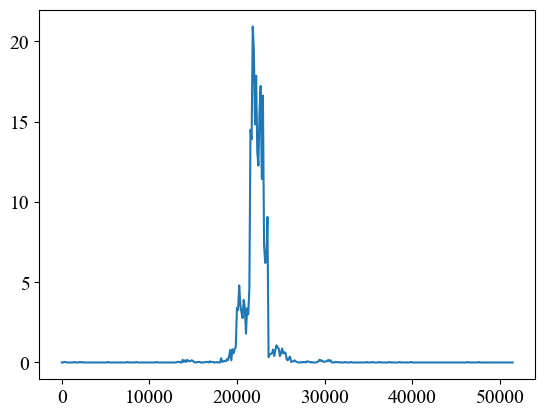

In [21]:
plt.plot(x,z)

In [22]:
stride = 1

Data Analysis:
Data points: 400
X range: [0.00, 51471.00]
Z range: [0.00, 20.93]
Z mean: 0.6963, Z std: 2.8313

Selected 3 features at x positions: [21801. 21930. 22962.]
Estimated amplitudes: [20.93333333 19.36666667 16.63333333]

Initial guess:
Peak 1: A=20.9333, Center=21801.0000, Width=838.5000
Peak 2: A=19.3667, Center=21930.0000, Width=838.5000
Peak 3: A=16.6333, Center=22962.0000, Width=838.5000
Baseline: 0.0000

Trying multiple fitting strategies

Strategy 1 (curve_fit with bounds): R² = 0.954703
Strategy 2 (differential evolution): R² = 0.895960

FITTED PARAMETERS:
Peak 1: A=3.6630±0.5216, Center=20253.9628±32.1760, Width=221.5975±46.6700
Peak 2: A=17.8821±0.4964, Center=21857.0943±9.3730, Width=307.9358±16.3749
Peak 3: A=14.1183±0.4106, Center=22726.3310±15.9637, Width=433.9405±24.0220
Baseline offset: -0.0544±0.0327

Fit Quality:
  R² = 0.954703
  RMSE = 0.602581


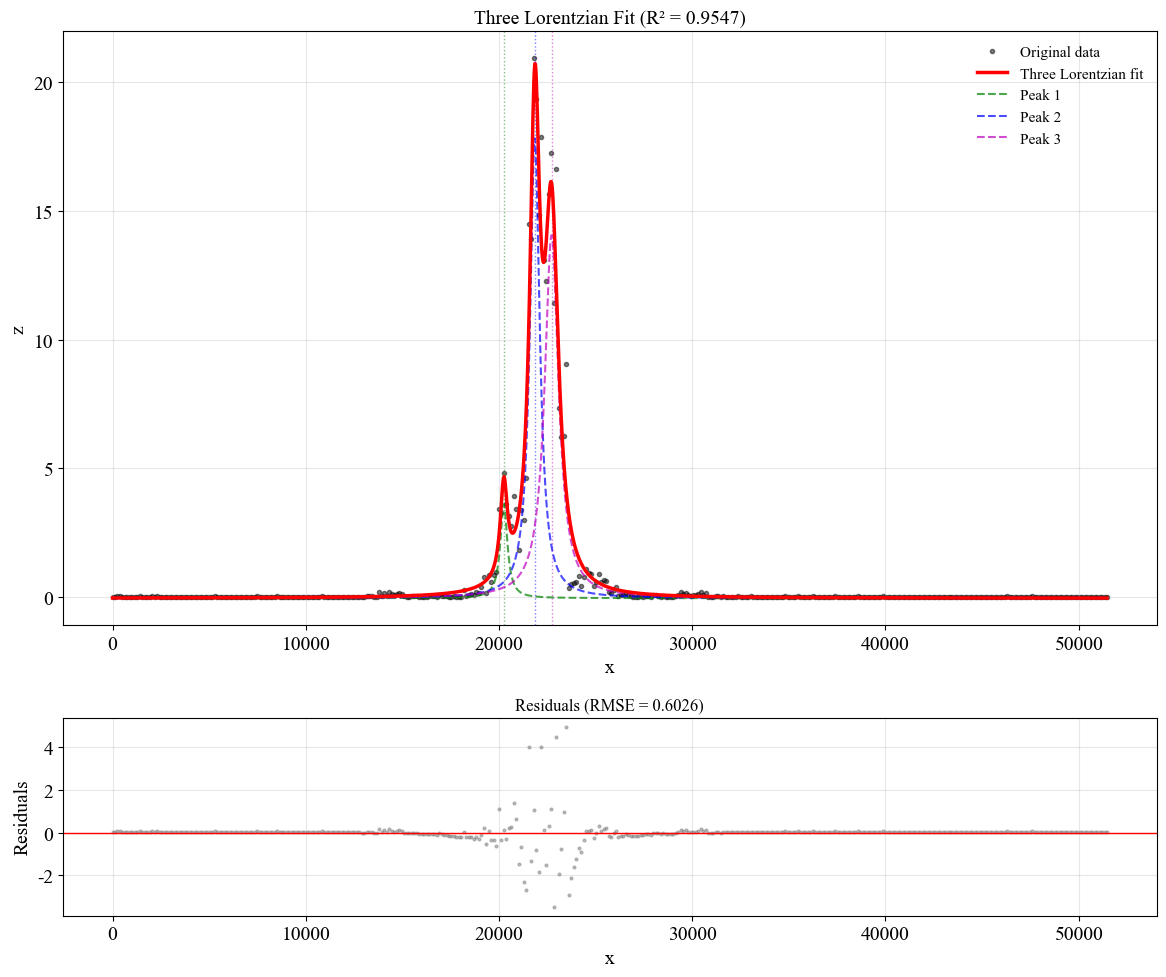

In [24]:
# Define single Lorentzian function
def lorentzian(x, A, x0, gamma):
    """
    Lorentzian function: L(x) = A / (1 + ((x - x0) / gamma)^2)
    
    Parameters:
        A: Peak amplitude
        x0: Peak center position
        gamma: Half-width at half-maximum (HWHM)
    """
    return A / (1 + ((x - x0) / gamma)**2)

# Define combination of three Lorentzian functions
def three_lorentzian(x, A1, x01, gamma1, A2, x02, gamma2, A3, x03, gamma3, offset):
    """
    Sum of three Lorentzian functions with a baseline offset
    """
    return (lorentzian(x, A1, x01, gamma1) + 
            lorentzian(x, A2, x02, gamma2) + 
            lorentzian(x, A3, x03, gamma3) + 
            offset)

# Analyze data structure first
x_min, x_max = np.min(x), np.max(x)
z_min, z_max = np.min(z), np.max(z)
x_range = x_max - x_min
z_range = z_max - z_min

print("Data Analysis:")
print(f"Data points: {len(x)}")
print(f"X range: [{np.min(x):.2f}, {np.max(x):.2f}]")
print(f"Z range: [{np.min(z):.2f}, {np.max(z):.2f}]")
print(f"Z mean: {np.mean(z):.4f}, Z std: {np.std(z):.4f}\n")

# smooth data
z_smooth = gaussian_filter1d(z, sigma=1.5)  # Adaptive smoothing

# Find peaks in original data
peaks1, props1 = find_peaks(z, height=np.mean(z), prominence=0.05*np.ptp(z_smooth), distance=1.5)
# print(peaks1)
# print(props1)

# Find peaks in smoothed data
peaks2, props2 = find_peaks(z_smooth, height=np.min(z) + z_range*0.1, prominence=0.05*np.ptp(z_smooth), distance=1.5)
# print(peaks2)
# print(props2)


# Combine all detected features
all_features = np.concatenate([peaks1, peaks2])
# print(all_features)
all_prominences = np.concatenate([props1["prominences"], props2["prominences"]])
# print(all_prominences)


# Select best 3 features based on prominence
baseline_est = np.median(z)
if len(all_features) >= 3:
    sorted_idx = np.argsort(all_prominences)[::-1][:3]
    selected_features = all_features[sorted_idx]
    sort_order = np.argsort(x[selected_features])
    peak_indices = selected_features[sort_order]
    peak_positions = x[peak_indices]
    peak_values = z[peak_indices]
    
    # Estimate amplitudes
    peak_amplitudes = peak_values - baseline_est
    
else:
    # Fallback: divide data into 3 regions and find max/min in each
    print("Using region-based approach")
    n_regions = 3
    region_size = len(x) // n_regions
    peak_indices = []
    peak_amplitudes = []
    
    for i in range(n_regions):
        start_idx = i * region_size
        end_idx = (i + 1) * region_size if i < n_regions - 1 else len(x)
        region_z = z[start_idx:end_idx]
        region_x = x[start_idx:end_idx]
        
        # Find max or min (whichever is more prominent)
        max_idx = start_idx + np.argmax(region_z)
        min_idx = start_idx + np.argmin(region_z)
        
        if abs(z[max_idx] - np.mean(region_z)) > abs(z[min_idx] - np.mean(region_z)):
            peak_indices.append(max_idx)
            peak_amplitudes.append(z[max_idx] - np.mean(z))
        else:
            peak_indices.append(min_idx)
            peak_amplitudes.append(z[min_idx] - np.mean(z))
    
    peak_positions = x[peak_indices]
    peak_amplitudes = np.array(peak_amplitudes)
    
print(f"Selected 3 features at x positions: {peak_positions}")
print(f"Estimated amplitudes: {peak_amplitudes}\n")

# Estimate width, try to find FWHM for each peak
estimated_widths = []

for peak_idx in peak_indices:
    peak_val = z[peak_idx]
    
    # Find points where signal is halfway between peak and baseline
    target = baseline_est + (peak_val - baseline_est) / 2
    left_idx = peak_idx
    right_idx = peak_idx
    
    # Find left half-max point
    while left_idx > 0 and (z[left_idx] - target) * (peak_val - baseline_est) > 0:
        left_idx -= 1

    # Find right half-max point
    while right_idx < len(z) - 1 and (z[right_idx] - target) * (peak_val - baseline_est) > 0:
        right_idx += 1

    width_est = (x[right_idx] - x[left_idx]) / 2 if right_idx > left_idx else x_range * 0.02
    # print(type(estimated_widths))
    estimated_widths.append(width_est)
estimated_widths = np.array(estimated_widths)

# Build initial guess
initial_guess = [
    peak_amplitudes[0], peak_positions[0], estimated_widths[0],  # Peak 1
    peak_amplitudes[1], peak_positions[1], estimated_widths[1],  # Peak 2
    peak_amplitudes[2], peak_positions[2], estimated_widths[2],  # Peak 3
    baseline_est  # offset
]

print("Initial guess:")
print(f"Peak 1: A={initial_guess[0]:.4f}, Center={initial_guess[1]:.4f}, Width={initial_guess[2]:.4f}")
print(f"Peak 2: A={initial_guess[3]:.4f}, Center={initial_guess[4]:.4f}, Width={initial_guess[5]:.4f}")
print(f"Peak 3: A={initial_guess[6]:.4f}, Center={initial_guess[7]:.4f}, Width={initial_guess[8]:.4f}")
print(f"Baseline: {initial_guess[9]:.4f}\n")

# Set bounds
lower_bounds = [
    0, x_min, x_range * 0.001,  # Peak 1
    0, x_min, x_range * 0.001,  # Peak 2
    0, x_min, x_range * 0.001,  # Peak 3
    z_min - z_range * 0.5  # offset
]

upper_bounds = [
    z_range * 3, x_max, x_range * 0.3,  # Peak 1
    z_range * 3, x_max, x_range * 0.3,  # Peak 2
    z_range * 3, x_max, x_range * 0.3,  # Peak 3
    z_max + z_range * 0.5  # offset
]

# Define objective function for optimization
def objective(params):
    try:
        y_pred = three_lorentzian(x, *params)
        return np.sum((z - y_pred)**2)
    except:
        return 1e10

# Try multiple fitting strategies
best_r2 = -np.inf
best_popt = None
best_pcov = None

print("Trying multiple fitting strategies\n")

# Strategy 1: Standard curve_fit with bounds
try:
    popt1, pcov1 = curve_fit(
        three_lorentzian, x, z, 
        p0=initial_guess, 
        bounds=(lower_bounds, upper_bounds),
        maxfev=100000,
        method='trf'
    )
    z_pred1 = three_lorentzian(x, *popt1)
    ss_res1 = np.sum((z - z_pred1)**2)
    ss_tot1 = np.sum((z - np.mean(z))**2)
    r2_1 = 1 - (ss_res1 / ss_tot1)
    print(f"Strategy 1 (curve_fit with bounds): R² = {r2_1:.6f}")
    if r2_1 > best_r2:
        best_r2 = r2_1
        best_popt = popt1
        best_pcov = pcov1
except Exception as e:
    print(f"Strategy 1 failed: {e}")


# Strategy 2: Differential evolution
try:
    result = differential_evolution(
        objective,
        bounds=list(zip(lower_bounds, upper_bounds)),
        seed=42,
        maxiter=1000,
        popsize=15,
        tol=1e-6
    )
    popt2 = result.x
    z_pred2 = three_lorentzian(x, *popt2)
    ss_res2 = np.sum((z - z_pred2)**2)
    ss_tot2 = np.sum((z - np.mean(z))**2)
    r2_2 = 1 - (ss_res2 / ss_tot2)
    print(f"Strategy 2 (differential evolution): R² = {r2_2:.6f}")
    if r2_2 > best_r2:
        best_r2 = r2_2
        best_popt = popt2
        # Refine with curve_fit
        try:
            best_popt, best_pcov = curve_fit(
                three_lorentzian, x, z, 
                p0=best_popt, 
                bounds=(lower_bounds, upper_bounds),
                maxfev=50000
            )
            z_pred_refined = three_lorentzian(x, *best_popt)
            ss_res_refined = np.sum((z - z_pred_refined)**2)
            ss_tot_refined = np.sum((z - np.mean(z))**2)
            best_r2 = 1 - (ss_res_refined / ss_tot_refined)
            print(f"  After refinement: R² = {best_r2:.6f}")
        except:
            pass
except Exception as e:
    print(f"Strategy 2 failed: {e}")

# Strategy 3: Multiple random starts
if best_r2 < 0.9:  # If still not good, try random starts
    print("Trying random starting points...")
    for attempt in range(5):
        try:
            # Random initial guess within bounds
            random_guess = [
                np.random.uniform(lower_bounds[0], upper_bounds[0]),  # A1
                np.random.uniform(lower_bounds[1], upper_bounds[1]),  # x01
                np.random.uniform(lower_bounds[2], upper_bounds[2]),  # gamma1
                np.random.uniform(lower_bounds[3], upper_bounds[3]),  # A2
                np.random.uniform(lower_bounds[4], upper_bounds[4]),  # x02
                np.random.uniform(lower_bounds[5], upper_bounds[5]),  # gamma2
                np.random.uniform(lower_bounds[6], upper_bounds[6]),  # A3
                np.random.uniform(lower_bounds[7], upper_bounds[7]),  # x03
                np.random.uniform(lower_bounds[8], upper_bounds[8]),  # gamma3
                np.random.uniform(lower_bounds[9], upper_bounds[9]),  # offset
            ]
            
            popt3, pcov3 = curve_fit(
                three_lorentzian, x, z, 
                p0=random_guess, 
                bounds=(lower_bounds, upper_bounds),
                maxfev=50000,
                method='trf'
            )
            z_pred3 = three_lorentzian(x, *popt3)
            ss_res3 = np.sum((z - z_pred3)**2)
            ss_tot3 = np.sum((z - np.mean(z))**2)
            r2_3 = 1 - (ss_res3 / ss_tot3)
            if r2_3 > best_r2:
                best_r2 = r2_3
                best_popt = popt3
                best_pcov = pcov3
        except:
            continue
    print(f"Best from random starts: R² = {best_r2:.6f}")

# Use best result
if best_popt is not None:
    popt = best_popt
    
    # Calculate uncertainties if covariance matrix is available
    if best_pcov is not None:
        try:
            param_errors = np.sqrt(np.diag(best_pcov))
        except:
            param_errors = np.zeros(10)
    else:
        param_errors = np.zeros(10)
    
    # Extract fitted parameters
    A1, x01, gamma1, A2, x02, gamma2, A3, x03, gamma3, offset = popt
    
    # Calculate fitted curve
    x_fit = np.linspace(np.min(x), np.max(x), 2000)
    z_fit = three_lorentzian(x_fit, *popt)
    
    # Calculate individual Lorentzian peaks
    z1_fit = lorentzian(x_fit, A1, x01, gamma1) + offset
    z2_fit = lorentzian(x_fit, A2, x02, gamma2) + offset
    z3_fit = lorentzian(x_fit, A3, x03, gamma3) + offset
    
    # Calculate fit quality metrics
    z_pred = three_lorentzian(x, *popt)
    ss_res = np.sum((z - z_pred)**2)
    ss_tot = np.sum((z - np.mean(z))**2)
    r_squared = 1 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((z - z_pred)**2))
    
    # Print results
    print("\n" + "="*60)
    print("FITTED PARAMETERS:")
    print("="*60)
    if np.any(param_errors > 0):
        print(f"Peak 1: A={A1:.4f}±{param_errors[0]:.4f}, Center={x01:.4f}±{param_errors[1]:.4f}, Width={gamma1:.4f}±{param_errors[2]:.4f}")
        print(f"Peak 2: A={A2:.4f}±{param_errors[3]:.4f}, Center={x02:.4f}±{param_errors[4]:.4f}, Width={gamma2:.4f}±{param_errors[5]:.4f}")
        print(f"Peak 3: A={A3:.4f}±{param_errors[6]:.4f}, Center={x03:.4f}±{param_errors[7]:.4f}, Width={gamma3:.4f}±{param_errors[8]:.4f}")
        print(f"Baseline offset: {offset:.4f}±{param_errors[9]:.4f}")
    else:
        print(f"Peak 1: A={A1:.4f}, Center={x01:.4f}, Width={gamma1:.4f}")
        print(f"Peak 2: A={A2:.4f}, Center={x02:.4f}, Width={gamma2:.4f}")
        print(f"Peak 3: A={A3:.4f}, Center={x03:.4f}, Width={gamma3:.4f}")
        print(f"Baseline offset: {offset:.4f}")
    print(f"\nFit Quality:")
    print(f"  R² = {r_squared:.6f}")
    print(f"  RMSE = {rmse:.6f}")
    print("="*60)
    
    # Plot results
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1])
    
    # Main plot
    ax1.plot(x, z, 'o', markersize=3, label='Original data', alpha=0.5, color='black', zorder=1)
    ax1.plot(x_fit, z_fit, 'r-', linewidth=2.5, label='Three Lorentzian fit', zorder=5)
    ax1.plot(x_fit, z1_fit, 'g--', linewidth=1.5, alpha=0.7, label='Peak 1', zorder=3)
    ax1.plot(x_fit, z2_fit, 'b--', linewidth=1.5, alpha=0.7, label='Peak 2', zorder=3)
    ax1.plot(x_fit, z3_fit, 'm--', linewidth=1.5, alpha=0.7, label='Peak 3', zorder=3)
    
    # Mark peak centers
    ax1.axvline(x01, color='g', linestyle=':', alpha=0.5, linewidth=1)
    ax1.axvline(x02, color='b', linestyle=':', alpha=0.5, linewidth=1)
    ax1.axvline(x03, color='m', linestyle=':', alpha=0.5, linewidth=1)
    
    ax1.set_xlabel('x', fontsize=14)
    ax1.set_ylabel('z', fontsize=14)
    ax1.legend(fontsize=11, loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.set_title(f'Three Lorentzian Fit (R² = {r_squared:.4f})', fontsize=14)
    
    # Residual plot
    residuals = z - z_pred
    ax2.plot(x, residuals, 'o', markersize=2, alpha=0.5, color='gray')
    ax2.axhline(0, color='r', linestyle='-', linewidth=1)
    ax2.set_xlabel('x', fontsize=14)
    ax2.set_ylabel('Residuals', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.set_title(f'Residuals (RMSE = {rmse:.4f})', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("All fitting strategies failed!")




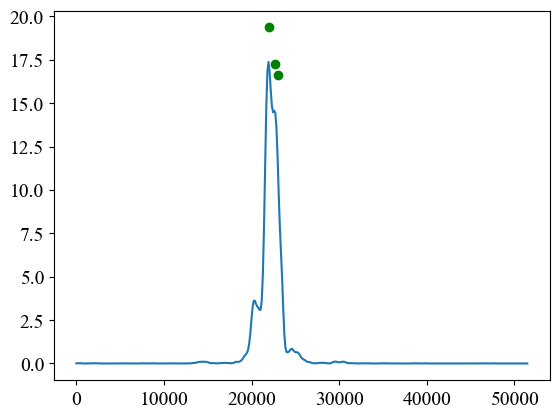

In [307]:
# plt.plot(x,z_smooth_gaussian)
# plt.plot(x,z_smooth_SG)
# plt.plot(x,z_smooth)

# plt.plot(x,z)
# plt.scatter(x[peaks2],z[peaks2], c = 'r')
plt.scatter(peak_positions,peak_values, c = "g")
plt.plot(x,z_smooth)
plt.show()


# plt.scatter(x[peaks3],z_smooth[peaks3],c = 'r')


In [29]:
def fit_three_lorentzian(x, z, verbose=False):
    """
    Fit three Lorentzian functions to 1D data.
    
    Parameters:
    -----------
    x : array-like
        Independent variable (e.g., frequency)
    z : array-like
        Dependent variable (e.g., counts)
    verbose : bool
        If True, print detailed fitting information
        
    Returns:
    --------
    popt : array
        Fitted parameters [A1, x01, gamma1, A2, x02, gamma2, A3, x03, gamma3, offset]
    pcov : array
        Covariance matrix
    r_squared : float
        R-squared value
    """
    from scipy.signal import find_peaks
    from scipy.optimize import differential_evolution
    from scipy.ndimage import gaussian_filter1d
    
    # Define single Lorentzian function
    def lorentzian(x, A, x0, gamma):
        return A / (1 + ((x - x0) / gamma)**2)
    
    # Define combination of three Lorentzian functions
    def three_lorentzian(x, A1, x01, gamma1, A2, x02, gamma2, A3, x03, gamma3, offset):
        return (lorentzian(x, A1, x01, gamma1) + 
                lorentzian(x, A2, x02, gamma2) + 
                lorentzian(x, A3, x03, gamma3) + 
                offset)
    
    x = np.array(x)
    z = np.array(z)
    
    # Try multiple peak detection strategies
    z_smooth = gaussian_filter1d(z, sigma=max(1, len(x)//200))
    # z_smooth = medfilt(z, kernel_size=5)
    
    # Strategy 1: Find peaks in original data
    peaks1, props1 = find_peaks(z, height=np.mean(z), distance=len(x)//20)
    
    # Strategy 2: Find peaks in smoothed data
    z_range = np.max(z) - np.min(z)
    peaks2, props2 = find_peaks(z_smooth, height=np.min(z) + z_range*0.1, distance=len(x)//15)
    
    # Strategy 3: Find both peaks and valleys (for dips)
    peaks3, props3 = find_peaks(-z_smooth, height=-(np.max(z) - z_range*0.1), distance=len(x)//15)
    
    # Combine all detected features
    all_features = np.unique(np.concatenate([peaks1, peaks2, peaks3]) if len(peaks3) > 0 else np.concatenate([peaks1, peaks2]))
    all_features = all_features[(all_features > 0) & (all_features < len(x)-1)]
    
    # Select best 3 features based on prominence
    if len(all_features) >= 3:
        prominences = []
        for idx in all_features:
            left_min = np.min(z[max(0, idx-len(x)//20):idx])
            right_min = np.min(z[idx:min(len(z), idx+len(x)//20)])
            prominence = z[idx] - max(left_min, right_min)
            prominences.append(abs(prominence))
        
        sorted_idx = np.argsort(prominences)[::-1][:3]
        selected_features = all_features[sorted_idx]
        sort_order = np.argsort(x[selected_features])
        peak_indices = selected_features[sort_order]
        peak_positions = x[peak_indices]
        peak_values = z[peak_indices]
        baseline_est = np.median(z)
        peak_amplitudes = peak_values - baseline_est
    else:
        # Fallback: divide data into 3 regions
        n_regions = 3
        region_size = len(x) // n_regions
        peak_indices = []
        peak_amplitudes = []
        
        for i in range(n_regions):
            start_idx = i * region_size
            end_idx = (i + 1) * region_size if i < n_regions - 1 else len(x)
            region_z = z[start_idx:end_idx]
            
            max_idx = start_idx + np.argmax(region_z)
            min_idx = start_idx + np.argmin(region_z)
            
            if abs(z[max_idx] - np.mean(region_z)) > abs(z[min_idx] - np.mean(region_z)):
                peak_indices.append(max_idx)
                peak_amplitudes.append(z[max_idx] - np.mean(z))
            else:
                peak_indices.append(min_idx)
                peak_amplitudes.append(z[min_idx] - np.mean(z))
        
        peak_positions = x[peak_indices]
        peak_amplitudes = np.array(peak_amplitudes)
    
    # Estimate width - try to find FWHM for each peak
    x_range = np.max(x) - np.min(x)
    estimated_widths = []
    
    for i, pos in enumerate(peak_positions):
        idx = np.argmin(np.abs(x - pos))
        peak_val = z[idx]
        baseline_local = np.median(z[max(0, idx-len(x)//10):min(len(z), idx+len(x)//10)])
        
        target = baseline_local + (peak_val - baseline_local) / 2
        left_idx = idx
        right_idx = idx
        
        while left_idx > 0 and (z[left_idx] - target) * (peak_val - baseline_local) > 0:
            left_idx -= 1
        while right_idx < len(z) - 1 and (z[right_idx] - target) * (peak_val - baseline_local) > 0:
            right_idx += 1
        
        width_est = (x[right_idx] - x[left_idx]) / 2 if right_idx > left_idx else x_range * 0.02
        estimated_widths.append(max(width_est, x_range * 0.005))
    
    estimated_widths = np.array(estimated_widths)
    baseline = np.median(z)
    
    # Build initial guess
    initial_guess = [
        peak_amplitudes[0], peak_positions[0], estimated_widths[0],
        peak_amplitudes[1], peak_positions[1], estimated_widths[1],
        peak_amplitudes[2], peak_positions[2], estimated_widths[2],
        baseline
    ]
    
    # Set bounds
    x_min, x_max = np.min(x), np.max(x)
    z_min, z_max = np.min(z), np.max(z)
    z_range = z_max - z_min
    x_range = x_max - x_min
    
    lower_bounds = [
        -z_range * 3, x_min, x_range * 0.001,
        -z_range * 3, x_min, x_range * 0.001,
        -z_range * 3, x_min, x_range * 0.001,
        z_min - z_range * 0.5
    ]
    
    upper_bounds = [
        z_range * 3, x_max, x_range * 0.3,
        z_range * 3, x_max, x_range * 0.3,
        z_range * 3, x_max, x_range * 0.3,
        z_max + z_range * 0.5
    ]
    
    # Define objective function
    def objective(params):
        try:
            y_pred = three_lorentzian(x, *params)
            return np.sum((z - y_pred)**2)
        except:
            return 1e10
    
    # Try multiple fitting strategies
    best_r2 = -np.inf
    best_popt = None
    best_pcov = None
    
    # Strategy 1: Standard curve_fit with bounds
    try:
        popt1, pcov1 = curve_fit(
            three_lorentzian, x, z, 
            p0=initial_guess, 
            bounds=(lower_bounds, upper_bounds),
            maxfev=100000,
            method='trf'
        )
        z_pred1 = three_lorentzian(x, *popt1)
        ss_res1 = np.sum((z - z_pred1)**2)
        ss_tot1 = np.sum((z - np.mean(z))**2)
        r2_1 = 1 - (ss_res1 / ss_tot1)
        if verbose:
            print(f"Strategy 1 (curve_fit with bounds): R² = {r2_1:.6f}")
        if r2_1 > best_r2:
            best_r2 = r2_1
            best_popt = popt1
            best_pcov = pcov1
    except:
        pass
    
    # Strategy 2: Differential evolution
    try:
        result = differential_evolution(
            objective,
            bounds=list(zip(lower_bounds, upper_bounds)),
            seed=42,
            maxiter=1000,
            popsize=15,
            tol=1e-6
        )
        popt2 = result.x
        z_pred2 = three_lorentzian(x, *popt2)
        ss_res2 = np.sum((z - z_pred2)**2)
        ss_tot2 = np.sum((z - np.mean(z))**2)
        r2_2 = 1 - (ss_res2 / ss_tot2)
        if verbose:
            print(f"Strategy 2 (differential evolution): R² = {r2_2:.6f}")
        if r2_2 > best_r2:
            best_r2 = r2_2
            best_popt = popt2
            # Refine with curve_fit
            try:
                best_popt, best_pcov = curve_fit(
                    three_lorentzian, x, z, 
                    p0=best_popt, 
                    bounds=(lower_bounds, upper_bounds),
                    maxfev=50000
                )
                z_pred_refined = three_lorentzian(x, *best_popt)
                ss_res_refined = np.sum((z - z_pred_refined)**2)
                ss_tot_refined = np.sum((z - np.mean(z))**2)
                best_r2 = 1 - (ss_res_refined / ss_tot_refined)
                if verbose:
                    print(f"  After refinement: R² = {best_r2:.6f}")
            except:
                pass
    except:
        pass
    
    # Strategy 3: Random starts
    if best_r2 < 0.9:
        for attempt in range(3):
            try:
                random_guess = [np.random.uniform(lb, ub) for lb, ub in zip(lower_bounds, upper_bounds)]
                popt3, pcov3 = curve_fit(
                    three_lorentzian, x, z, 
                    p0=random_guess, 
                    bounds=(lower_bounds, upper_bounds),
                    maxfev=50000,
                    method='trf'
                )
                z_pred3 = three_lorentzian(x, *popt3)
                ss_res3 = np.sum((z - z_pred3)**2)
                ss_tot3 = np.sum((z - np.mean(z))**2)
                r2_3 = 1 - (ss_res3 / ss_tot3)
                if r2_3 > best_r2:
                    best_r2 = r2_3
                    best_popt = popt3
                    best_pcov = pcov3
            except:
                continue
    
    if best_popt is None:
        raise ValueError("All fitting strategies failed!")
    
    # Calculate R-squared
    z_pred = three_lorentzian(x, *best_popt)
    ss_res = np.sum((z - z_pred)**2)
    ss_tot = np.sum((z - np.mean(z))**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    return best_popt, best_pcov, r_squared


In [30]:
def process_2d_lorentzian_fitting(x, y, Z, verbose=False):
    """
    Process 2D data by fitting three Lorentzians for each voltage (x) value,
    then fit quadratic functions to each peak branch.
    
    Parameters:
    -----------
    x : array-like
        Voltage values (1D array)
    y : array-like
        Frequency values (1D array)
    Z : array-like
        2D array with shape (len(x), len(y)) - counts at each (voltage, frequency)
    verbose : bool
        If True, print progress information
        
    Returns:
    --------
    results : dict
        Dictionary containing:
        - 'peak_centers': array of shape (len(x), 3) - peak centers for each voltage
        - 'peak_amplitudes': array of shape (len(x), 3) - peak amplitudes
        - 'peak_widths': array of shape (len(x), 3) - peak widths
        - 'r_squared': array of shape (len(x),) - R² for each fit
        - 'quadratic_fits': list of 3 tuples (coeffs, r2) for quadratic fits of each branch
        - 'sorted_peaks': array of shape (len(x), 3) - peaks sorted by position
    """
    x = np.array(x)
    y = np.array(y)
    Z = np.array(Z)
    
    if Z.shape != (len(x), len(y)):
        raise ValueError(f"Z shape {Z.shape} does not match expected shape ({len(x)}, {len(y)})")
    
    # Storage for results
    peak_centers = np.full((len(x), 3), np.nan)
    peak_amplitudes = np.full((len(x), 3), np.nan)
    peak_widths = np.full((len(x), 3), np.nan)
    r_squared = np.full(len(x), np.nan)
    
    # Fit three Lorentzians for each voltage
    if verbose:
        print(f"Fitting three Lorentzians for {len(x)} voltage values...")
    
    for i, voltage in enumerate(x):
        z_slice = Z[i, :]
        
        # Skip if all values are NaN or zero
        if np.all(np.isnan(z_slice)) or np.all(z_slice == 0):
            continue
        
        try:
            popt, pcov, r2 = fit_three_lorentzian(y, z_slice, verbose=False)
            
            # Extract parameters: [A1, x01, gamma1, A2, x02, gamma2, A3, x03, gamma3, offset]
            peak_centers[i, 0] = popt[1]  # x01
            peak_centers[i, 1] = popt[4]  # x02
            peak_centers[i, 2] = popt[7]  # x03
            
            peak_amplitudes[i, 0] = popt[0]  # A1
            peak_amplitudes[i, 1] = popt[3]  # A2
            peak_amplitudes[i, 2] = popt[6]  # A3
            
            peak_widths[i, 0] = popt[2]  # gamma1
            peak_widths[i, 1] = popt[5]  # gamma2
            peak_widths[i, 2] = popt[8]  # gamma3
            
            r_squared[i] = r2
            
        except Exception as e:
            if verbose:
                print(f"Warning: Fit failed for voltage {voltage:.4f}: {e}")
            continue
    
    # Sort peaks by position for each voltage to create branches
    # We want to track which peak belongs to which branch across voltages
    sorted_peaks = np.full((len(x), 3), np.nan)
    
    # Initialize branch assignment using first valid voltage
    first_valid_idx = np.where(~np.isnan(peak_centers[:, 0]))[0]
    if len(first_valid_idx) > 0:
        first_idx = first_valid_idx[0]
        initial_order = np.argsort(peak_centers[first_idx, :])
        
        # For each voltage, sort peaks and assign to branches
        for i in range(len(x)):
            if not np.any(np.isnan(peak_centers[i, :])):
                # Sort peaks by position
                sort_idx = np.argsort(peak_centers[i, :])
                sorted_peaks[i, :] = peak_centers[i, sort_idx]
            else:
                # Try to assign based on nearest neighbor
                if i > 0 and not np.any(np.isnan(sorted_peaks[i-1, :])):
                    # Use previous voltage's order as guide
                    current_centers = peak_centers[i, :]
                    if not np.any(np.isnan(current_centers)):
                        # Match each current peak to nearest previous peak
                        prev_centers = sorted_peaks[i-1, :]
                        assignment = []
                        used = []
                        for prev_center in prev_centers:
                            distances = [abs(c - prev_center) if j not in used else np.inf 
                                        for j, c in enumerate(current_centers)]
                            nearest_idx = np.argmin(distances)
                            assignment.append(nearest_idx)
                            used.append(nearest_idx)
                        sorted_peaks[i, :] = current_centers[assignment]
    
    # Fit quadratic functions to each branch
    quadratic_fits = []
    
    def quadratic(x, a, b, c):
        return a * x**2 + b * x + c
    
    for branch_idx in range(3):
        # Extract branch data (peak center vs voltage)
        branch_centers = sorted_peaks[:, branch_idx]
        valid_mask = ~np.isnan(branch_centers)
        
        if np.sum(valid_mask) < 3:  # Need at least 3 points for quadratic
            quadratic_fits.append((None, np.nan))
            continue
        
        x_valid = x[valid_mask]
        y_valid = branch_centers[valid_mask]
        
        try:
            # Fit quadratic
            quad_coeffs, quad_cov = curve_fit(quadratic, x_valid, y_valid)
            y_pred_quad = quadratic(x_valid, *quad_coeffs)
            ss_res_quad = np.sum((y_valid - y_pred_quad)**2)
            ss_tot_quad = np.sum((y_valid - np.mean(y_valid))**2)
            r2_quad = 1 - (ss_res_quad / ss_tot_quad) if ss_tot_quad > 0 else np.nan
            
            quadratic_fits.append((quad_coeffs, r2_quad))
            
        except Exception as e:
            if verbose:
                print(f"Warning: Quadratic fit failed for branch {branch_idx}: {e}")
            quadratic_fits.append((None, np.nan))
    
    results = {
        'peak_centers': peak_centers,
        'peak_amplitudes': peak_amplitudes,
        'peak_widths': peak_widths,
        'r_squared': r_squared,
        'quadratic_fits': quadratic_fits,
        'sorted_peaks': sorted_peaks
    }
    
    return results


In [31]:
def plot_2d_lorentzian_results(x, y, Z, results, xlabel='Voltage (V)', ylabel='Frequency (kHz)', zlabel='Counts'):
    """
    Plot the 2D data with fitted peaks and quadratic fits.
    
    Parameters:
    -----------
    x : array-like
        Voltage values
    y : array-like
        Frequency values
    Z : array-like
        2D data array
    results : dict
        Results from process_2d_lorentzian_fitting
    xlabel, ylabel, zlabel : str
        Labels for axes
    """
    def quadratic(x, a, b, c):
        return a * x**2 + b * x + c
    
    fig = plt.figure(figsize=(16, 10))
    
    # Top: 2D map with peak positions overlaid
    ax1 = plt.subplot(2, 2, 1)
    im = ax1.pcolormesh(x, y, Z.T, shading='auto', cmap='viridis')
    plt.colorbar(im, ax=ax1, label=zlabel)
    
    # Plot sorted peaks for each branch
    colors = ['red', 'blue', 'green']
    labels = ['Branch 1', 'Branch 2', 'Branch 3']
    
    for branch_idx in range(3):
        branch_centers = results['sorted_peaks'][:, branch_idx]
        valid_mask = ~np.isnan(branch_centers)
        if np.any(valid_mask):
            ax1.plot(x[valid_mask], branch_centers[valid_mask], 
                    'o', color=colors[branch_idx], markersize=4, 
                    label=labels[branch_idx], alpha=0.7)
            
            # Plot quadratic fit if available
            quad_fit = results['quadratic_fits'][branch_idx]
            if quad_fit[0] is not None:
                x_fit = np.linspace(np.min(x[valid_mask]), np.max(x[valid_mask]), 200)
                y_fit = quadratic(x_fit, *quad_fit[0])
                ax1.plot(x_fit, y_fit, '--', color=colors[branch_idx], 
                        linewidth=2, alpha=0.8, label=f'{labels[branch_idx]} (quadratic)')
    
    ax1.set_xlabel(xlabel, fontsize=12)
    ax1.set_ylabel(ylabel, fontsize=12)
    ax1.set_title('2D Map with Fitted Peaks and Quadratic Fits', fontsize=14)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Middle left: Peak positions vs voltage (branches)
    ax2 = plt.subplot(2, 2, 2)
    for branch_idx in range(3):
        branch_centers = results['sorted_peaks'][:, branch_idx]
        valid_mask = ~np.isnan(branch_centers)
        if np.any(valid_mask):
            ax2.plot(x[valid_mask], branch_centers[valid_mask], 
                    'o', color=colors[branch_idx], markersize=5, 
                    label=labels[branch_idx], alpha=0.7)
            
            # Plot quadratic fit
            quad_fit = results['quadratic_fits'][branch_idx]
            if quad_fit[0] is not None:
                x_fit = np.linspace(np.min(x[valid_mask]), np.max(x[valid_mask]), 200)
                y_fit = quadratic(x_fit, *quad_fit[0])
                ax2.plot(x_fit, y_fit, '--', color=colors[branch_idx], 
                        linewidth=2, alpha=0.8)
                # Print quadratic coefficients
                a, b, c = quad_fit[0]
                r2 = quad_fit[1]
                ax2.text(0.05, 0.95 - branch_idx*0.1, 
                        f'{labels[branch_idx]}: y = {a:.2e}x² + {b:.2e}x + {c:.2e} (R²={r2:.4f})',
                        transform=ax2.transAxes, fontsize=9, 
                        verticalalignment='top', color=colors[branch_idx])
    
    ax2.set_xlabel(xlabel, fontsize=12)
    ax2.set_ylabel('Peak Center ' + ylabel, fontsize=12)
    ax2.set_title('Peak Positions vs Voltage (Sorted Branches)', fontsize=14)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # Middle right: Peak amplitudes vs voltage
    ax3 = plt.subplot(2, 2, 3)
    for branch_idx in range(3):
        # Need to map sorted peaks back to original amplitudes
        branch_centers = results['sorted_peaks'][:, branch_idx]
        valid_mask = ~np.isnan(branch_centers)
        if np.any(valid_mask):
            # Find corresponding amplitudes
            amplitudes = np.full(len(x), np.nan)
            for i in range(len(x)):
                if valid_mask[i]:
                    # Find which original peak this corresponds to
                    center_val = branch_centers[i]
                    for orig_idx in range(3):
                        if abs(results['peak_centers'][i, orig_idx] - center_val) < 1e-6:
                            amplitudes[i] = results['peak_amplitudes'][i, orig_idx]
                            break
            
            ax3.plot(x[valid_mask], amplitudes[valid_mask], 
                    'o', color=colors[branch_idx], markersize=5, 
                    label=labels[branch_idx], alpha=0.7)
    
    ax3.set_xlabel(xlabel, fontsize=12)
    ax3.set_ylabel('Peak Amplitude', fontsize=12)
    ax3.set_title('Peak Amplitudes vs Voltage', fontsize=14)
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    
    # Bottom: Fit quality (R²) vs voltage
    ax4 = plt.subplot(2, 2, 4)
    valid_r2 = ~np.isnan(results['r_squared'])
    ax4.plot(x[valid_r2], results['r_squared'][valid_r2], 'o-', 
            color='black', markersize=4, linewidth=1)
    ax4.axhline(0.9, color='green', linestyle='--', alpha=0.5, label='R² = 0.9')
    ax4.axhline(0.7, color='orange', linestyle='--', alpha=0.5, label='R² = 0.7')
    ax4.set_xlabel(xlabel, fontsize=12)
    ax4.set_ylabel('R² (Fit Quality)', fontsize=12)
    ax4.set_title('Lorentzian Fit Quality vs Voltage', fontsize=14)
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim([0, 1.1])
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*70)
    print("QUADRATIC FIT SUMMARY")
    print("="*70)
    for branch_idx in range(3):
        quad_fit = results['quadratic_fits'][branch_idx]
        if quad_fit[0] is not None:
            a, b, c = quad_fit[0]
            r2 = quad_fit[1]
            print(f"\nBranch {branch_idx + 1}:")
            print(f"  y = {a:.6e} x² + {b:.6e} x + {c:.6e}")
            print(f"  R² = {r2:.6f}")
        else:
            print(f"\nBranch {branch_idx + 1}: Fit failed or insufficient data")
    print("="*70)


Processing 2D data...
Voltage range: 11 points from -1.00 to 1.00
Frequency range: 400 points from 0.00 to 102942.00
Data shape: (11, 400)

Fitting three Lorentzians for 11 voltage values...


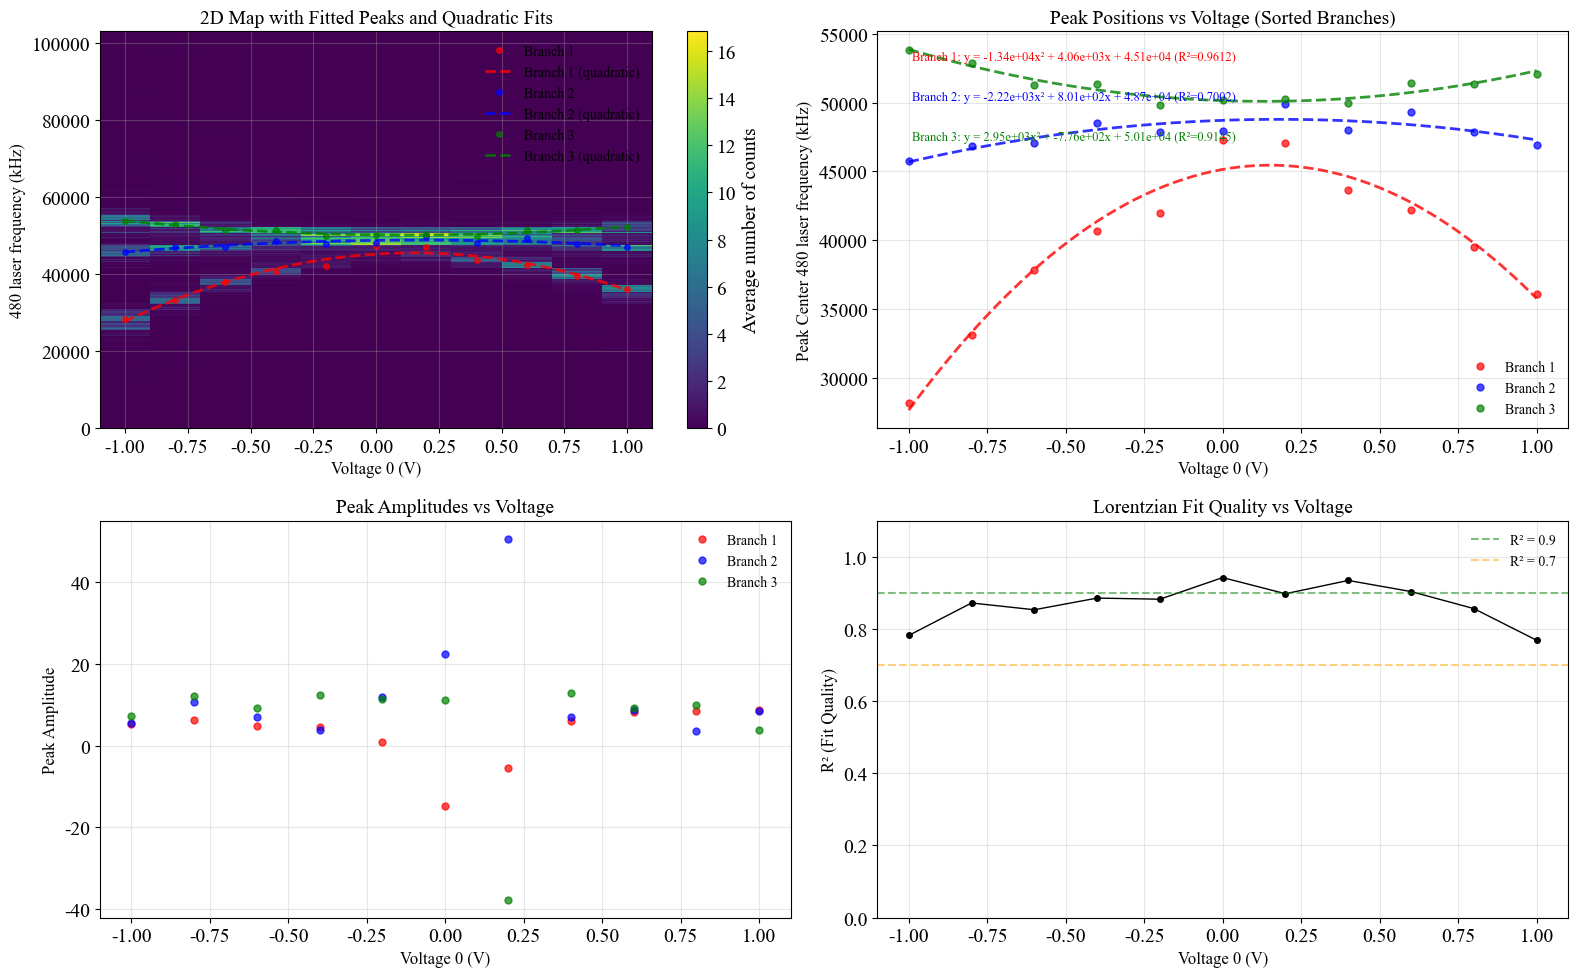


QUADRATIC FIT SUMMARY

Branch 1:
  y = -1.343723e+04 x² + 4.060593e+03 x + 4.513953e+04
  R² = 0.961215

Branch 2:
  y = -2.223200e+03 x² + 8.012925e+02 x + 4.870831e+04
  R² = 0.700175

Branch 3:
  y = 2.950777e+03 x² + -7.759380e+02 x + 5.013967e+04
  R² = 0.914546


In [32]:
# Example usage for 2D data
# Check if data is 2D (has y dimension)
# Note: z might be 1D or 2D depending on data type
Z_data = z if y is None else z  # Use z as Z for 2D data

if y is not None:
    # Convert to 2D if needed
    if z.ndim == 1:
        print("Warning: y is provided but z is 1D. Expected 2D data.")
        print("For 1D data, use: popt, pcov, r2 = fit_three_lorentzian(x, z, verbose=True)")
    elif z.ndim == 2:
        print("Processing 2D data...")
        print(f"Voltage range: {len(x)} points from {np.min(x):.2f} to {np.max(x):.2f}")
        print(f"Frequency range: {len(y)} points from {np.min(y):.2f} to {np.max(y):.2f}")
        print(f"Data shape: {z.shape}\n")
        
        # Process the 2D data
        results = process_2d_lorentzian_fitting(x, y, z, verbose=True)
        
        # Plot results
        # Extract labels from notes if available
        xlabel = notes.get('xlabel', 'Voltage (V)')
        ylabel = notes.get('ylabel', 'Frequency (kHz)')
        zlabel = notes.get('zlabel', 'Counts')
        
        plot_2d_lorentzian_results(x, y, z, results, xlabel=xlabel, ylabel=ylabel, zlabel=zlabel)
    else:
        print(f"Unexpected data dimension: {z.ndim}")
else:
    print("Data is 1D. For 2D processing, ensure y is not None and z is 2D.")
    print("For 1D data, use: popt, pcov, r2 = fit_three_lorentzian(x, z, verbose=True)")


In [26]:
root_dir = "X:/migratedData/Rydberg_QIS/data"
x,y,z,notes = Readout.read_saved_csv_by_id(root_dir=root_dir, date="2025/12/11", plot_id=3)

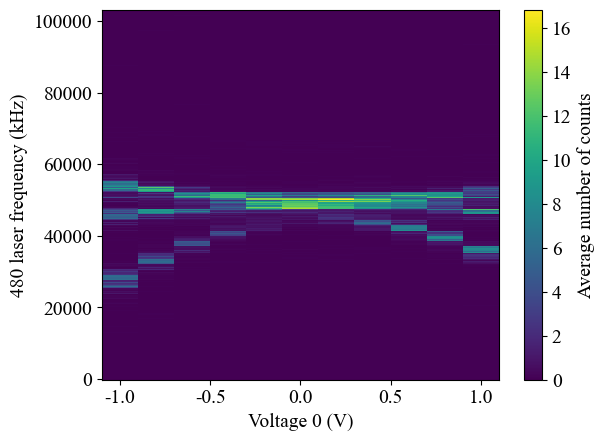

In [27]:
plt.pcolormesh(x,y,z.T)
plt.xlabel(notes["xlabel"])
plt.ylabel(notes["ylabel"])
cbar = plt.colorbar()
cbar.set_label(notes["zlabel"])